### Computer Assignment: Sparse Image Recovery

This exercise confirms the feasibility of compressed sensing on real signals, particularly images, where the sparsity level $S$ is unknown and there might be noise in the collected measurements. 

The sensing schemes under consideration are: **Random Gaussian** and **Random Subsampling** (directly in the pixel domain) as we have described in previous assignments. You will find the following three images: *Phantom* (synthetic), *Brain* (real) and *Boat* (real). 

The sparsifying matrix that you should consider is the **IDCT basis** (just like in the JPEG compression standard). You would like to use a small patch size, say $8 \times 8$ or $16 \times 16$. 

Compute the distortion based on the **Peak Signal-to-Noise Ratio (PSNR)**, defined as follows:

$$\text{PSNR} = 10 \log_{10} \left( \frac{\text{MAX}^2}{\text{MSE}} \right)$$

where the Mean Squared Error (MSE) is:

$$\text{MSE} = \frac{1}{N^2} \|\hat{x} - x\|_2^2$$

For our three test images, $\text{MAX} = 255$ (the maximum dynamic range) and $N$ is the image dimension. You should also implement a function to compute PSNR so that you can plot the PSNR between the recovered images and the original with respect to various numbers of measurements $M$.

**Questions to answer based on your observations:**
* What are your observations on how to obtain the best recovery performance?
* Which sensing scheme is better? 
* Which sensing scheme is faster? 
* How many measurements do you need to take to get a reasonable recovery? 
* On average, what is the approximate sparsity level of each image here?

In [26]:
# First import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from scipy.fftpack import dct, idct
from tqdm import tqdm

# Import code from previous homework
from HW2 import (
    set_random_seed,
    solve_l1_linear_programming,
    solve_matching_pursuit,
    solve_orthogonal_matching_pursuit,
    solve_subspace_pursuit,
    solve_cosamp,
    plot_measurement_matrix
)
from HW3 import (
    generate_measurement_matrix_orthonormal_random,
    generate_measurement_matrix_random_frequency
)

In [27]:
# Set random seed for reproducibility
set_random_seed(42)

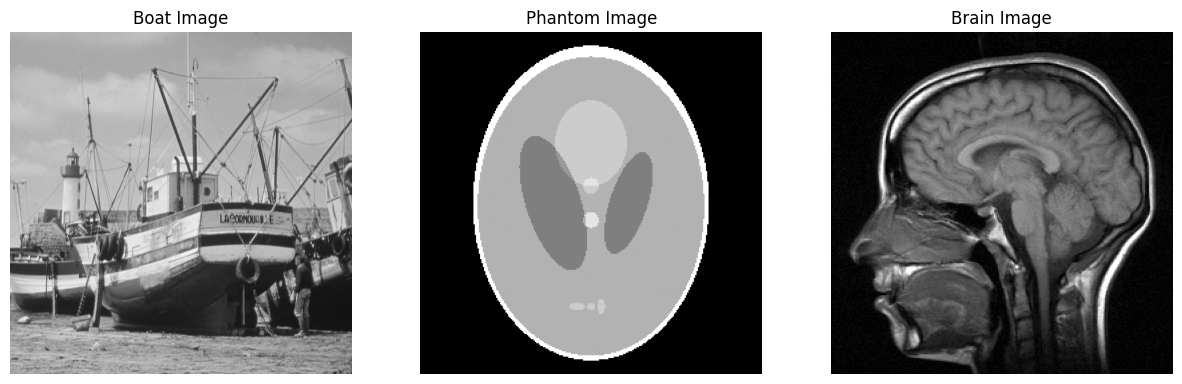

In [28]:
# Load the images
DATA_FOLDER = "../data/"

BOAT_IMAGE_PATH = DATA_FOLDER + "boat.tif"
PHANTOM_IMAGE_PATH = DATA_FOLDER + "phantom.gif"
BRAIN_IMAGE_PATH = DATA_FOLDER + "brain.gif"

# Read the images and convert to grayscale
boat_image = cv.imread(BOAT_IMAGE_PATH, cv.IMREAD_GRAYSCALE)
phantom_image = cv.imread(PHANTOM_IMAGE_PATH, cv.IMREAD_GRAYSCALE)
brain_image = cv.imread(BRAIN_IMAGE_PATH, cv.IMREAD_GRAYSCALE)

# Display the images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(boat_image, cmap="gray")
plt.title("Boat Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(phantom_image, cmap="gray")
plt.title("Phantom Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(brain_image, cmap="gray")
plt.title("Brain Image")
plt.axis("off")

plt.show()

In [29]:
# Make a function to convert the image to many patches of size 16x16, and then vectorize each patch to get a matrix of size (256, num_patches)
PATCH_SIZE = 16
N = PATCH_SIZE * PATCH_SIZE  # Number of pixels in each patch
def image_to_patches(image, patch_size=16):
    """
    Convert an image to patches of size patch_size x patch_size, and vectorize each patch.
    
    Parameters:
        image (numpy array): Input image of shape (H, W).
        patch_size (int): Size of each patch (default is 16).
    
    Returns:
        numpy array: Matrix of shape (patch_size**2, num_patches) containing the vectorized patches.
    """
    H, W = image.shape
    patches = []
    
    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            if patch.shape == (patch_size, patch_size):  # Only consider full patches
                patches.append(patch.flatten())
    
    return np.array(patches).T  # Return as (patch_size**2, num_patches)

Boat image patches shape: (256, 1024)


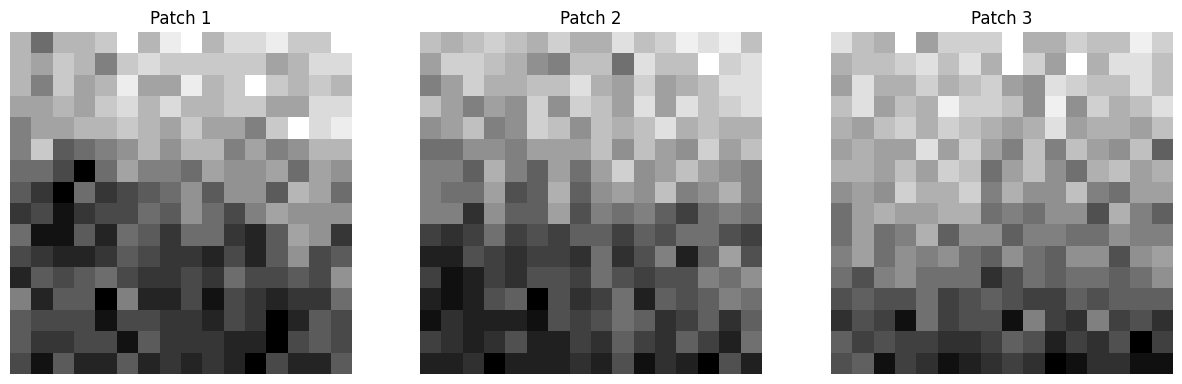

In [30]:
# Test the function on the boat image
boat_patches = image_to_patches(boat_image)
print("Boat image patches shape:", boat_patches.shape)
# Plot the first 3 patches as images
plt.figure(figsize=(15, 5))
for i in range(3):
    patch_image = boat_patches[:, i].reshape(PATCH_SIZE, PATCH_SIZE)
    plt.subplot(1, 3, i+1)
    plt.imshow(patch_image, cmap="gray")
    plt.title(f"Patch {i+1}")
    plt.axis("off")
plt.show()

In [ ]:
# A function to reconstruct a single patch from its vectorized form
ALGORITHMS = {
    "l1": solve_l1_linear_programming,
    "mp": lambda A, y: solve_matching_pursuit(A, y, tol=1e-6, max_iter=100),  # Use a tolerance for MP
    "omp": lambda A, y: solve_orthogonal_matching_pursuit(A, y, tol=1e-6, max_iter=100),  # Use a tolerance for OMP
    "sp": solve_subspace_pursuit,
    "cosamp": solve_cosamp
}

def reconstruct_patch(vectorized_patch, sensing_matrix, algorithm="omp", patch_size=16):
    """
    Reconstruct a patch from its vectorized form.
    
    Parameters:
        vectorized_patch (numpy array): Vectorized patch of shape (patch_size**2,).
        sensing_matrix (numpy array): Sensing matrix of shape (num_observations, patch_size**2).
        algorithm (str): The algorithm to use for reconstruction (default is "omp").
        patch_size (int): Size of the patch (default is 16).
    Returns:
        numpy array: Reconstructed patch of shape (patch_size, patch_size).
    """
    if algorithm not in ALGORITHMS:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    reconstruct_func = ALGORITHMS[algorithm]
    N = patch_size ** 2 # Total number of pixels in the patch

    # 1. Take the physical measurements (y = A * x)
    measurements = np.dot(sensing_matrix, vectorized_patch)

    # 2. Build the 2D IDCT Dictionary (Psi)
    # We create a 1D IDCT matrix, then use Kronecker product to make it 2D
    D1 = idct(np.eye(patch_size), norm='ortho', axis=0)
    Psi = np.kron(D1, D1)

    # 3. Create the Effective Sensing Matrix (Theta = A * Psi)
    Theta = np.dot(sensing_matrix, Psi)

    # 4. Solve for the sparse frequency coefficients (alpha)
    # WARNING: SP and CoSaMP require you to input a sparsity level 'S'.
    # Since S is unknown for images, we estimate it (e.g., 10% to 20% of N).
    if algorithm in ["sp", "cosamp"]:
        estimated_S = int(0.25 * N) # Guess that 25% of the frequencies are significant
        alpha_hat = reconstruct_func(Theta, measurements, S=estimated_S)
    else:
        # L1, MP, and OMP can usually run based on tolerance
        alpha_hat = reconstruct_func(Theta, measurements)
    
    # 5. Reconstruct the pixel patch (x_hat = Psi * alpha_hat)
    reconstructed_vector = np.dot(Psi, alpha_hat)

    # 6. Reshape back to 2D
    return reconstructed_vector.reshape((patch_size, patch_size))

In [32]:
M_VALUES = [int(0.1*i*N) for i in range(1, 5, 1)] # M from 10% to 50% of N, in steps of 10%

# Create the sensing matrix (A) for each M
random_gaussian_matrices = [generate_measurement_matrix_orthonormal_random(M, N) for M in M_VALUES]
random_fourier_matrices = [generate_measurement_matrix_random_frequency(M, N) for M in M_VALUES]

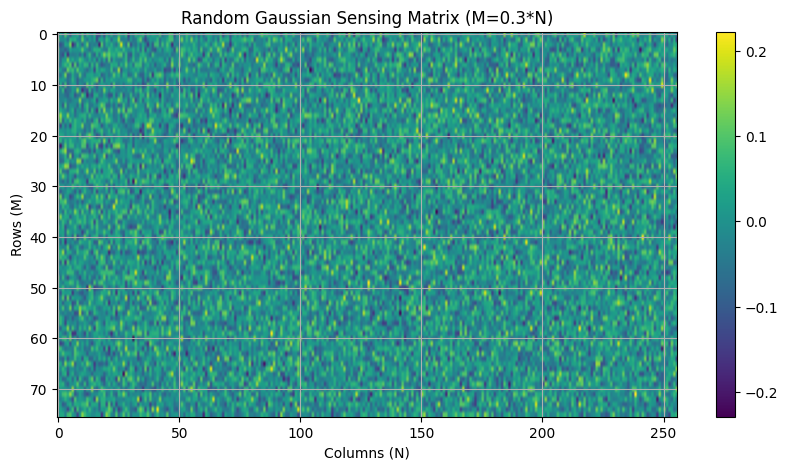

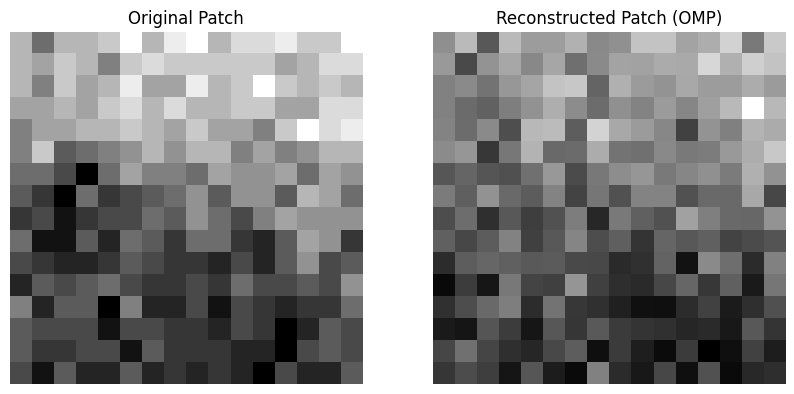

In [33]:
# Test the reconstruction on the first patch of the boat image using OMP and random Gaussian sensing matrix
test_patch_vector = boat_patches[:, 0]  # First patch
sensing_matrix = random_gaussian_matrices[2]  # Use the sensing matrix corresponding to M=30% of N
reconstructed_patch = reconstruct_patch(test_patch_vector, sensing_matrix, algorithm="omp", patch_size=PATCH_SIZE)

# Plot the sensing matrix as an image (reshaped to 16x16 for visualization)
plot_measurement_matrix(sensing_matrix, title="Random Gaussian Sensing Matrix (M=0.3*N)")

# Display the original and reconstructed patches
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_patch_vector.reshape(PATCH_SIZE, PATCH_SIZE), cmap="gray")
plt.title("Original Patch")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_patch, cmap="gray")
plt.title("Reconstructed Patch (OMP)")
plt.axis("off")
plt.show()

In [34]:
# Function to stitch the reconstructed patches back into a full image
def patches_to_image(patches, image_shape, patch_size=16):
    """
    Stitch the reconstructed patches back into a full image.
    
    Parameters:
        patches (numpy array): Matrix of shape (patch_size**2, num_patches) containing the vectorized patches.
        image_shape (tuple): The original image shape (H, W).
        patch_size (int): Size of each patch (default is 16).
    
    Returns:
        numpy array: Reconstructed image of shape (H, W).
    """
    H, W = image_shape
    reconstructed_image = np.zeros((H, W), dtype=np.float32)
    patch_idx = 0
    
    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            if patch_idx < patches.shape[1]:  # Check if we have enough patches
                patch_vector = patches[:, patch_idx]
                patch_image = patch_vector.reshape((patch_size, patch_size))
                reconstructed_image[i:i+patch_size, j:j+patch_size] = patch_image
                patch_idx += 1
    
    return reconstructed_image

# End to end function to reconstruct the entire image from patches
def reconstruct_image_from_patches(image, sensing_matrix, algorithm="omp", patch_size=16):
    """
    Reconstruct the entire image from its patches using compressed sensing.
    
    Parameters:
        image (numpy array): Input image of shape (H, W).
        sensing_matrix (numpy array): Sensing matrix to use for reconstruction.
        algorithm (str): The algorithm to use for reconstruction (default is "omp").
        patch_size (int): Size of each patch (default is 16).
    Returns:
        numpy array: Reconstructed image of shape (H, W).
    """
    # 1. Convert the image to patches
    patches = image_to_patches(image, patch_size)

    # 2. Reconstruct each patch
    reconstructed_patches = np.zeros_like(patches)
    for i in tqdm(range(patches.shape[1]), leave=False):
        reconstructed_patches[:, i] = reconstruct_patch(patches[:, i], sensing_matrix, algorithm, patch_size).flatten()

    # 3. Stitch the reconstructed patches back into a full image
    reconstructed_image = patches_to_image(reconstructed_patches, image.shape, patch_size)
    
    return reconstructed_image

In [35]:
# Test the reconstruction on the first patch of the boat image using OMP and random Gaussian sensing matrix
reconstructed_boat_image = reconstruct_image_from_patches(boat_image, sensing_matrix, algorithm="omp", patch_size=PATCH_SIZE)

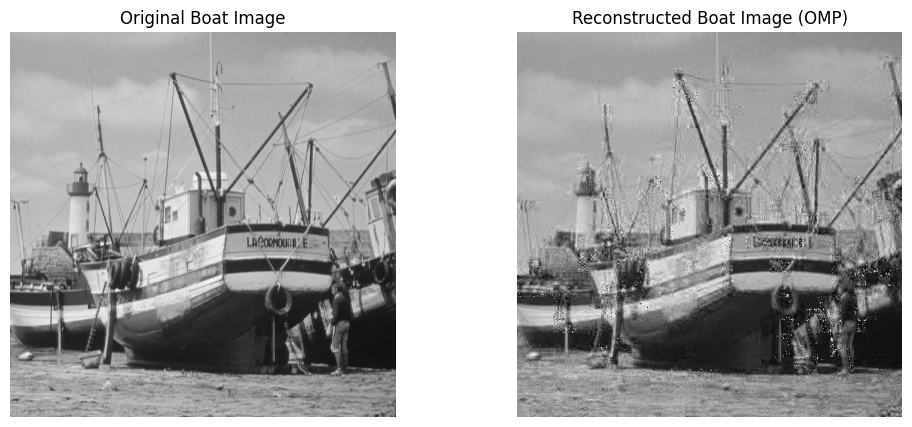

In [36]:
# Display the original and reconstructed images
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(boat_image, cmap="gray")
plt.title("Original Boat Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_boat_image, cmap="gray")
plt.title("Reconstructed Boat Image (OMP)")
plt.axis("off")
plt.show()

In [37]:
# Function to compute PSNR between original and reconstructed patch
def compute_psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')  # No error, PSNR is infinite
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

In [38]:
# Compute PSNR for the reconstructed boat image
psnr_value = compute_psnr(boat_image, reconstructed_boat_image)
print(f"PSNR of the reconstructed boat image: {psnr_value:.2f} dB")

PSNR of the reconstructed boat image: 22.71 dB


In [ ]:
# Function to test the reconstruction of one image with different sensing matrices and algorithms, and compute PSNR for each case
def test_reconstruction_with_different_matrices_and_algorithms(image, sensing_matrices, algorithms, patch_size=16):
    results = {}
    for sensing_matrix in (loop:=tqdm(sensing_matrices)):
        for algorithm in algorithms:
            reconstructed_image = reconstruct_image_from_patches(image, sensing_matrix, algorithm, patch_size)
            psnr_value = compute_psnr(image, reconstructed_image)
            results[(sensing_matrix.shape[0], algorithm)] = psnr_value
            loop.set_description(f"Testing M={sensing_matrix.shape[0]}, Algorithm={algorithm}, PSNR={psnr_value:.2f} dB")
    return results

In [40]:
# Test only l1 and OMP algorithms for the boat image with random Gaussian sensing matrices
algorithms_to_test = ["l1", "omp"]

# Test with random Gaussian sensing matrices
boat_results_r = test_reconstruction_with_different_matrices_and_algorithms(boat_image, random_gaussian_matrices, algorithms_to_test, patch_size=PATCH_SIZE)
phantom_results_r = test_reconstruction_with_different_matrices_and_algorithms(phantom_image, random_gaussian_matrices, algorithms_to_test, patch_size=PATCH_SIZE)
brain_results_r = test_reconstruction_with_different_matrices_and_algorithms(brain_image, random_gaussian_matrices, algorithms_to_test, patch_size=PATCH_SIZE)

# Test with random Fourier sensing matrices
boat_results_f = test_reconstruction_with_different_matrices_and_algorithms(boat_image, random_fourier_matrices, algorithms_to_test, patch_size=PATCH_SIZE)
phantom_results_f = test_reconstruction_with_different_matrices_and_algorithms(phantom_image, random_fourier_matrices, algorithms_to_test, patch_size=PATCH_SIZE)
brain_results_f = test_reconstruction_with_different_matrices_and_algorithms(brain_image, random_fourier_matrices, algorithms_to_test, patch_size=PATCH_SIZE)

In [41]:
# Function to plot the results of PSNR for different sensing matrices and algorithms
def plot_psnr_results(results, title):
    plt.figure(figsize=(10, 5))
    for algorithm in algorithms_to_test:
        psnr_values = [results[(M, algorithm)] for M in M_VALUES]
        plt.plot(M_VALUES, psnr_values, marker='o', label=f"{algorithm.upper()}")
    plt.title(title)
    plt.xlabel("Number of Measurements (M)")
    plt.ylabel("PSNR (dB)")
    plt.legend()
    plt.grid()
    plt.show()

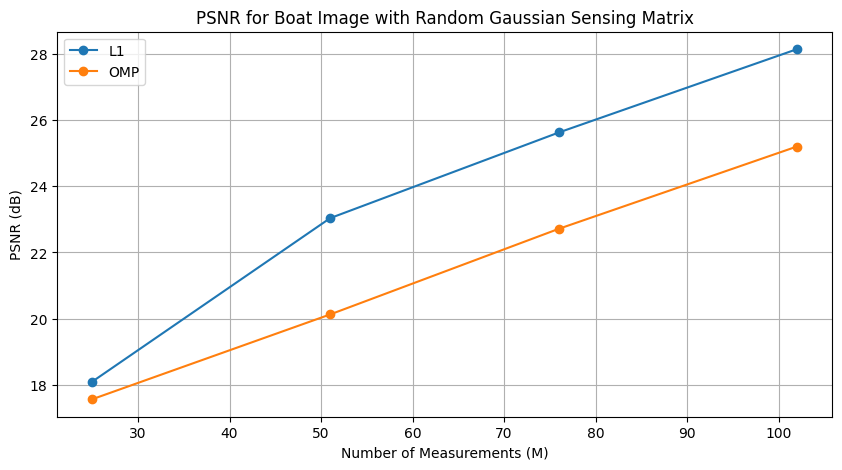

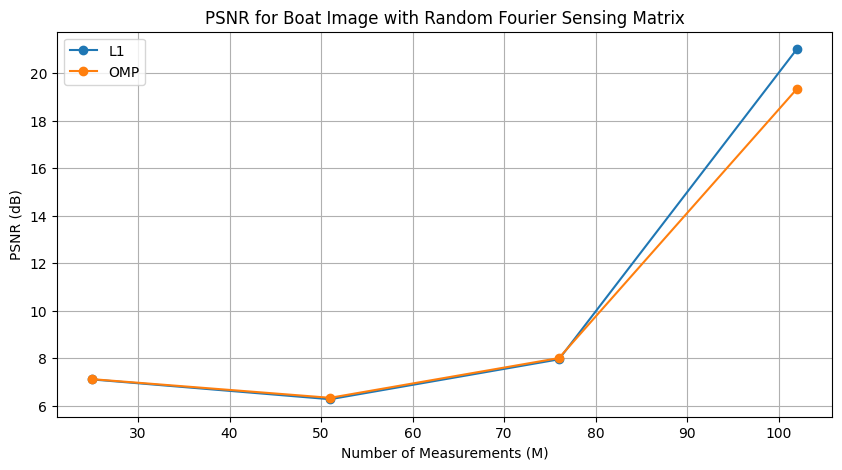

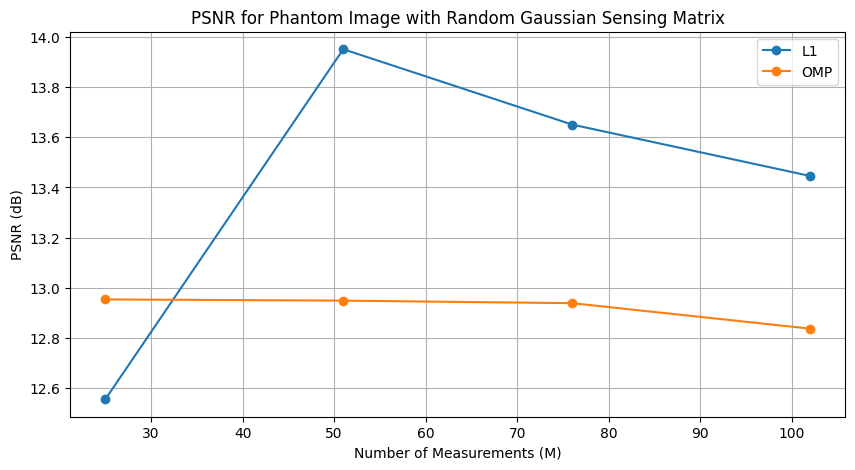

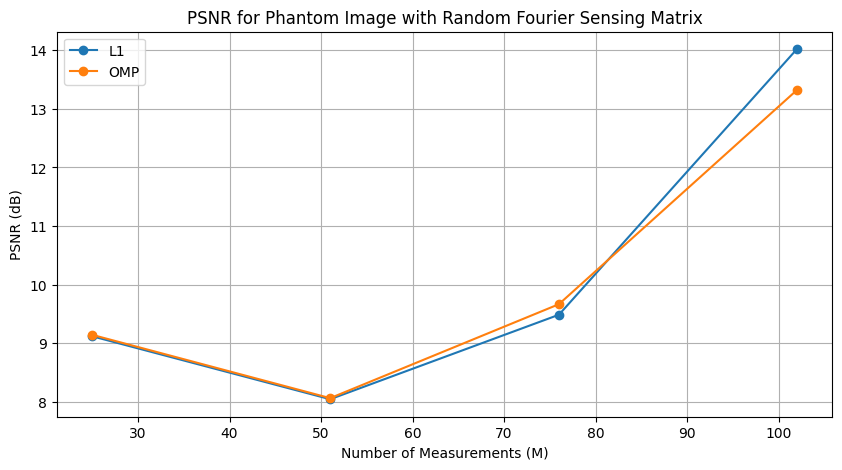

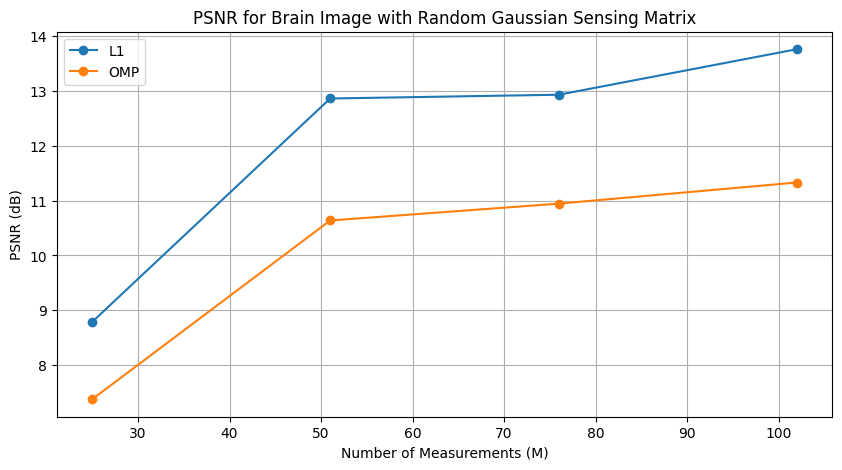

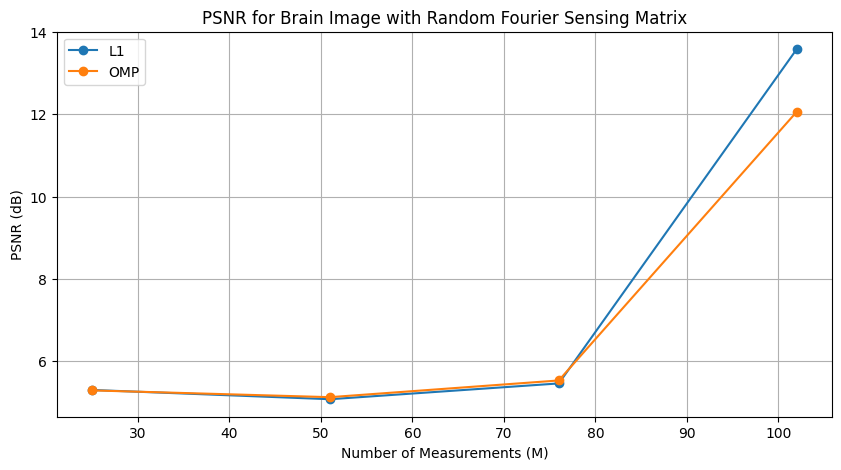

In [42]:
# Plot the PSNR results for different M and algorithms for boat image
plot_psnr_results(boat_results_r, "PSNR for Boat Image with Random Gaussian Sensing Matrix")
plot_psnr_results(boat_results_f, "PSNR for Boat Image with Random Fourier Sensing Matrix")

# Plot the PSNR results for different M and algorithms for phantom image
plot_psnr_results(phantom_results_r, "PSNR for Phantom Image with Random Gaussian Sensing Matrix")
plot_psnr_results(phantom_results_f, "PSNR for Phantom Image with Random Fourier Sensing Matrix")

# Plot the PSNR results for different M and algorithms for brain image
plot_psnr_results(brain_results_r, "PSNR for Brain Image with Random Gaussian Sensing Matrix")
plot_psnr_results(brain_results_f, "PSNR for Brain Image with Random Fourier Sensing Matrix")

In [43]:
boat_results_r, boat_results_f, phantom_results_r, phantom_results_f, brain_results_r, brain_results_f

({(25, 'l1'): np.float32(18.094358),
  (25, 'omp'): np.float32(17.562803),
  (51, 'l1'): np.float32(23.03506),
  (51, 'omp'): np.float32(20.125317),
  (76, 'l1'): np.float32(25.624754),
  (76, 'omp'): np.float32(22.713669),
  (102, 'l1'): np.float32(28.14014),
  (102, 'omp'): np.float32(25.198181)},
 {(25, 'l1'): np.float32(7.098859),
  (25, 'omp'): np.float32(7.1111794),
  (51, 'l1'): np.float32(6.2659826),
  (51, 'omp'): np.float32(6.325548),
  (76, 'l1'): np.float32(7.9466205),
  (76, 'omp'): np.float32(7.9996157),
  (102, 'l1'): np.float32(21.013275),
  (102, 'omp'): np.float32(19.336575)},
 {(25, 'l1'): np.float32(12.556466),
  (25, 'omp'): np.float32(12.954033),
  (51, 'l1'): np.float32(13.950644),
  (51, 'omp'): np.float32(12.949191),
  (76, 'l1'): np.float32(13.650629),
  (76, 'omp'): np.float32(12.939112),
  (102, 'l1'): np.float32(13.445902),
  (102, 'omp'): np.float32(12.837714)},
 {(25, 'l1'): np.float32(9.116731),
  (25, 'omp'): np.float32(9.140998),
  (51, 'l1'): np.float